# Double distillation column: the infinite horizon vs the finite horizon

The model is the declared double column from [`models/double_column.py`](models/double_column.py):
two 41-tray columns in series separating a ternary mixture, the DAE example.
The weir flows, vapor compositions, tray temperatures, and purity aliases are
algebraic and undeclared; they ride along with the declared states. Two cases
of the same model. Case 1 runs five sampling steps with the infinite-horizon
terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs the full twenty-five step finite horizon with the
terminal cost live.

Both cases initialize before the solve (`initialize.py`): the states
interpolate linearly from the initial condition to the steady state, and
the algebraic and cost variables then come from their defining equations
at those states. A stand-in until initialization lands in drto.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import pyomo_pounce  # registers pounce with the native factory
from pyomo.contrib.solver.common.factory import SolverFactory
import drto
from models.double_column import double_column
from drto import plot_states, plot_controls, plot_stage_cost
#import idaes
m1 = double_column(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
drto.cold_start_dynamic(m1)
SolverFactory("pounce").solve(m1, tee=True)
#SolverFactory("ipopt").solve(m1, options={"linear_solver": "ma57"}, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.11.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpk673iydw\unknownqtksa2z9.nl...


Parsed 26269 vars, 25895 cons, jac_nnz=127432, h_nnz=59698 in 0.09s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:   127272
Number of nonzeros in inequality constraint Jacobian.:      160
Number of nonzeros in Lagrangian Hessian.............:    59698

Total number of variables............................:    26269
                     variables with only lower bounds:     2940
                variables with lower and upper bounds:    15698
                     variables with only upper bounds:        0
Total number of equality constraints.................:    25863
Total number of inequality constraints...............:       32
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       32
        inequality constraints with only upper bounds:        0



iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  5.1145027e+03 5.05e+00 1.01e+02   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0


   1  3.0220028e+02 4.89e+00 9.87e+01   -1.0 2.09e+01      - 9.72e-03 3.16e-02f  1


   2  2.9020142e+03 4.35e+00 9.07e+01   -1.0 2.23e+01      - 1.15e-01 1.10e-01h  1


...

  69  2.7168952e+02 2.31e-09 3.26e-05   -8.6 2.34e-04      - 1.00e+00 1.00e+00f  1


iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  70  2.7168952e+02 9.13e-11 3.65e-08   -8.6 6.82e-05      - 1.00e+00 1.00e+00h  1


  71  2.7168952e+02 1.07e-11 4.16e-09   -8.6 2.37e-05      - 1.00e+00 1.00e+00h  1




Number of Iterations....: 71

                                   (scaled)                 (unscaled)
Objective...............:   2.7168951652698553e+01    2.7168951652698553e+02
Dual infeasibility......:   4.1606178189993102e-09    4.1606178189993102e-08
Constraint violation....:   1.0698553154497858e-11    1.0698553154497858e-11
Variable bound violation:   9.9874919807666677e-09    9.9874919807666677e-09
Complementarity.........:   2.8558282486374349e-09    2.8558282486374349e-08
Overall NLP error.......:   4.1606178189993102e-09    4.1606178189993102e-08

Violation of the model as declared (before the bound_relax_factor widening): 9.9874919807666677e-09


Number of objective function evaluations             = 75
Number of objective gradient evaluations             = 72
Number of equality constraint evaluations            = 75
Number of inequality constraint evaluations          = 75
Number of equality constraint Jacobian evaluations   = 72
Number of inequality constraint Jacobian e

C:\Users\Devin\AppData\Local\Temp\tmpk673iydw\unknownqtksa2z9.sol


In [2]:
drto.info(m1)

<drto registry>
states: 606, controls: 8
declarations:
  horizon: t (ContinuousSet, 16 points)
  states: x1 (free), x2 (free), M1 (free), M2 (free)
  dynamics: dM1[i,t]  ==  L1[11,t] - L1[i,t] + VB1[0] - VB1[0]  for i in tray, t in t
  dynamics: dx1[i,j,t]  ==  (L1[11,t]*(x1[11,j,t] - x1[i,j,t]) + VB1[0]*(y1[9,j,t] - x1[i,j,t]) - VB1[0]*(y1[i,j,t] - x1[i,j,t]))/M1[i,t]  for i in tray, j in comp, t in t
  dynamics: dM2[i,t]  ==  L2[11,t] - L2[i,t] + VB2[0] - VB2[0]  for i in tray, t in t
  dynamics: dx2[i,j,t]  ==  (L2[11,t]*(x2[11,j,t] - x2[i,j,t]) + VB2[0]*(y2[9,j,t] - x2[i,j,t]) - VB2[0]*(y2[i,j,t] - x2[i,j,t]))/M2[i,t]  for i in tray, j in comp, t in t
  controls: LT1 (piecewise_constant, free), VB1 (piecewise_constant, free), D1 (piecewise_constant, free), B1 (piecewise_constant, free), LT2 (piecewise_constant, free), VB2 (piecewise_constant, free), D2 (piecewise_constant, free), B2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (LT1[t] - LT1_ss)**2 + (VB1[t] - VB1_ss)**2 + (D1[t] - D1_ss)**2 + (B1[t] - B1_ss)**2 + (LT2[t] - LT2_ss)**2 + (VB2[t] - VB2_ss)**2 + (D2[t] - D2_ss)**2 + (B2[t] - B2_ss)**2 + 10*(SUM((x1[i,j,t] - x1_ss[i,j])**2 + (x2[i,j,t] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,t] - M1_ss[l])**2 + (M2[l,t] - M2_ss[l])**2 for l in tray))  for t in sorted(t)[:-1]
  terminal cost: term  ==  10*(SUM((x1[i,j,5] - x1_ss[i,j])**2 + (x2[i,j,5] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,5] - M1_ss[l])**2 + (M2[l,5] - M2_ss[l])**2 for l in tray))
  initial conditions: x1_hat[i,j]  ==  x1[i,j,0]  for i in tray, j in comp
  initial conditions: x2_hat[i,j]  ==  x2[i,j,0]  for i in tray, j in comp
  initial conditions: M1_hat[i]  ==  M1[i,0]  for i in tray
  initial conditions: M2_hat[i]  ==  M2[i,0]  for i in tray
  steady-state targets: x1_ss (of x1), x2_ss (of x2), M1_ss (of M1), M2_ss (of M2)
  steady-state control targets: LT1_ss (of LT1), VB1_ss (of VB1), D1_ss (of D1), B1_ss (of B1), LT2_ss (of LT2), VB2_ss (of VB2), D2_ss (of D2), B2_ss (of B2)
transformations:
  drto.infinite_horizon: segment=3 elements x 5 Legendre points, beta=1.2, gamma=0.01563827, profile=collocation, horizon=kept, infinite tail appended, algebraic=9 components replicated, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 4 states, mu=1000.0
  drto.parameterize: profiles=LT1 (piecewise_constant), VB1 (piecewise_constant), D1 (piecewise_constant), B1 (piecewise_constant), LT2 (piecewise_constant), VB2 (piecewise_constant), D2 (piecewise_constant), B2 (piecewise_constant)
  drto.build_objective: objective=sum of 1004 weighted cost terms

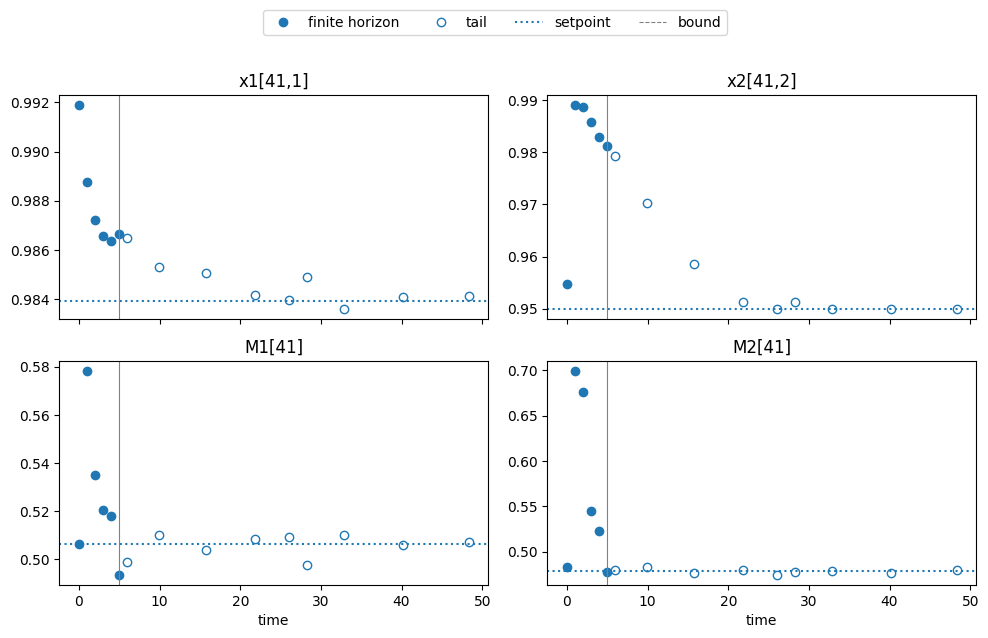

In [3]:
# multi-index states select by member: overhead purities and condenser holdups
plot_states(m1, states=["x1[41,1]", "x2[41,2]", "M1[41]", "M2[41]"]);

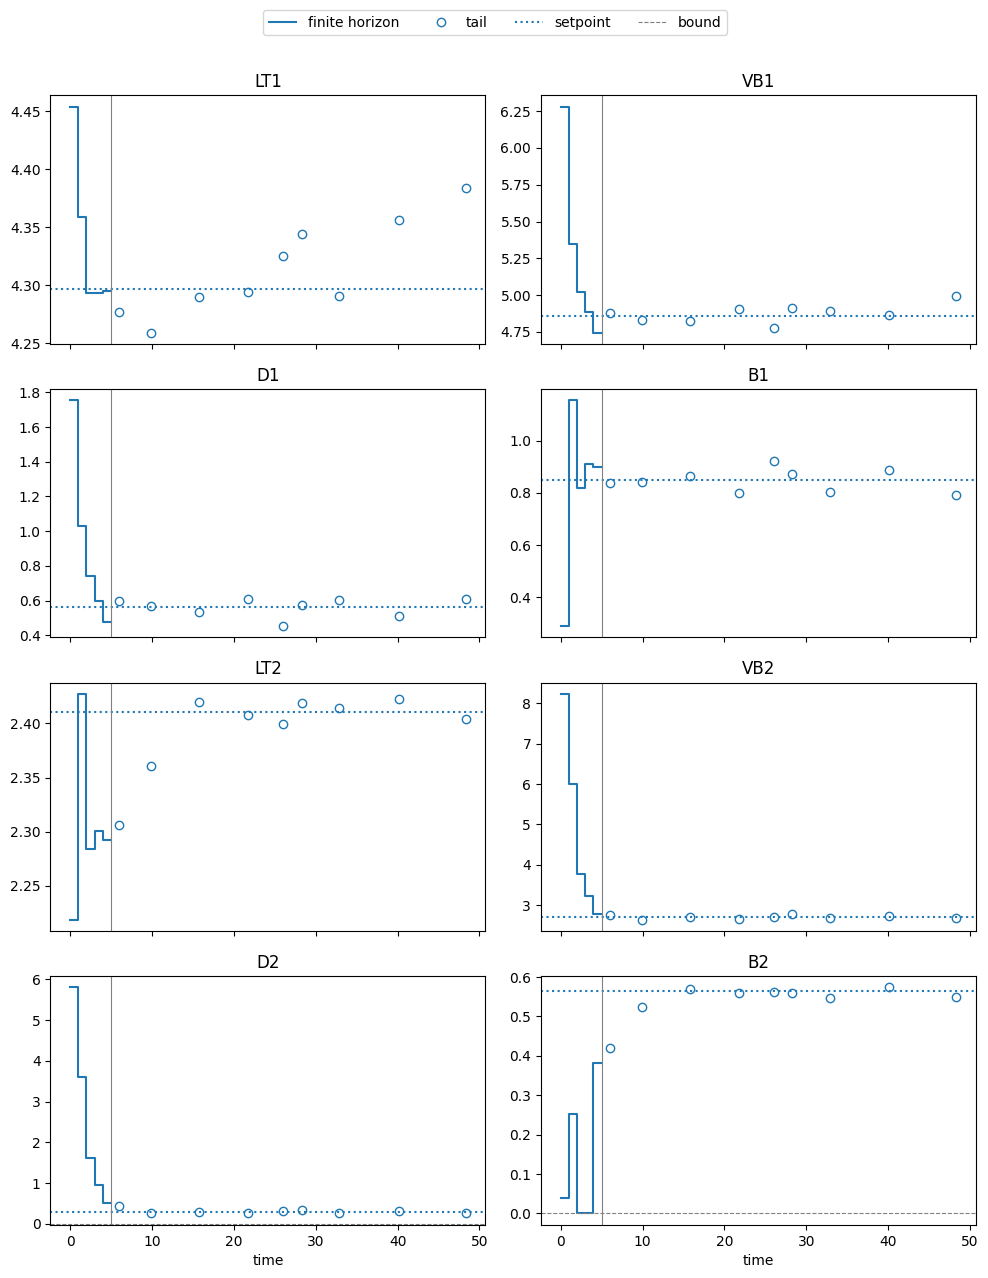

In [4]:
plot_controls(m1);

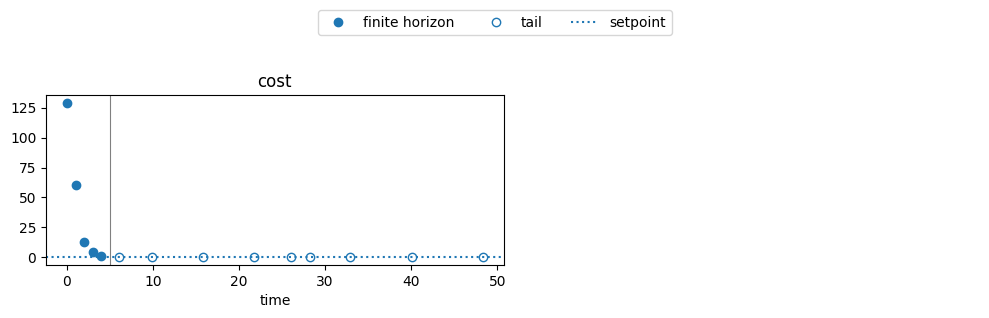

In [5]:
plot_stage_cost(m1);

## Case 2: twenty-five samples, finite horizon with the terminal cost

In [6]:
m2 = double_column(N=25)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=25, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
drto.cold_start_dynamic(m2)
SolverFactory("pounce").solve(m2, tee=True)
#SolverFactory("ipopt").solve(m2, options={"linear_solver": "ma57"}, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.11.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp02yly2za\unknown49olgrtg.nl...


Parsed 61685 vars, 61485 cons, jac_nnz=287815, h_nnz=143885 in 0.19s
Problem class: NLP. Selected solver: NLP filter line-search interior-point (pounce-nlp) [solver_selection=auto].

Number of nonzeros in equality constraint Jacobian...:   287815
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:   143885

Total number of variables............................:    61685
                     variables with only lower bounds:     6003
                variables with lower and upper bounds:    36960
                     variables with only upper bounds:        0
Total number of equality constraints.................:    61485
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0



iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  5.6421478e+02 5.05e+00 1.00e+00   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0


   1  5.6167681e+02 4.18e+00 4.17e+02   -1.0 1.56e+01      - 2.23e-01 1.72e-01f  1


   2  5.6305203e+02 4.15e+00 5.73e+02   -1.0 2.86e+01      - 1.93e-01 8.54e-03h  1


...

  93  2.0881656e+02 8.12e-14 4.75e-09   -5.7 5.64e-07      - 1.00e+00 1.00e+00h  1


  94  2.0881655e+02 4.67e-08 7.99e-02   -8.6 5.57e-04      - 9.99e-01 1.00e+00h  1


  95  2.0881655e+02 5.68e-14 6.69e-11   -8.6 5.14e-08      - 1.00e+00 1.00e+00h  1




Number of Iterations....: 95

                                   (scaled)                 (unscaled)
Objective...............:   2.0881655256813400e+02    2.0881655256813400e+02
Dual infeasibility......:   6.6869695115044883e-11    6.6869695115044883e-11
Constraint violation....:   5.6843418860808015e-14    5.6843418860808015e-14
Variable bound violation:   9.5461387683570820e-09    9.5461387683570820e-09
Complementarity.........:   2.5059041974829522e-09    2.5059041974829522e-09
Overall NLP error.......:   2.5059041974829522e-09    2.5059041974829522e-09

Violation of the model as declared (before the bound_relax_factor widening): 9.5461387683570820e-09


Number of objective function evaluations             = 96
Number of objective gradient evaluations             = 1
Number of equality constraint evaluations            = 96
Number of inequality constraint evaluations          = 96
Number of equality constraint Jacobian evaluations   = 96
Number of inequality constraint Jacobian ev

C:\Users\Devin\AppData\Local\Temp\tmp02yly2za\unknown49olgrtg.sol


In [7]:
drto.info(m2)

<drto registry>
states: 580, controls: 8
declarations:
  horizon: t (ContinuousSet, 76 points)
  states: x1 (free), x2 (free), M1 (free), M2 (free)
  dynamics: dM1[i,t]  ==  L1[11,t] - L1[i,t] + VB1[i] - VB1[i]  for i in tray, t in t
  dynamics: dx1[i,j,t]  ==  (L1[11,t]*(x1[11,j,t] - x1[i,j,t]) + VB1[i]*(y1[9,j,t] - x1[i,j,t]) - VB1[i]*(y1[i,j,t] - x1[i,j,t]))/M1[i,t]  for i in tray, j in comp, t in t
  dynamics: dM2[i,t]  ==  L2[11,t] - L2[i,t] + VB2[i] - VB2[i]  for i in tray, t in t
  dynamics: dx2[i,j,t]  ==  (L2[11,t]*(x2[11,j,t] - x2[i,j,t]) + VB2[i]*(y2[9,j,t] - x2[i,j,t]) - VB2[i]*(y2[i,j,t] - x2[i,j,t]))/M2[i,t]  for i in tray, j in comp, t in t
  controls: LT1 (piecewise_constant, free), VB1 (piecewise_constant, free), D1 (piecewise_constant, free), B1 (piecewise_constant, free), LT2 (piecewise_constant, free), VB2 (piecewise_constant, free), D2 (piecewise_constant, free), B2 (piecewise_constant, free)
  tracking stage cost: cost[t]  ==  (LT1[t] - LT1_ss)**2 + (VB1[t] - VB1_ss)**2 + (D1[t] - D1_ss)**2 + (B1[t] - B1_ss)**2 + (LT2[t] - LT2_ss)**2 + (VB2[t] - VB2_ss)**2 + (D2[t] - D2_ss)**2 + (B2[t] - B2_ss)**2 + 10*(SUM((x1[i,j,t] - x1_ss[i,j])**2 + (x2[i,j,t] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,t] - M1_ss[l])**2 + (M2[l,t] - M2_ss[l])**2 for l in tray))  for t in sorted(t)[:-1]
  terminal cost: term  ==  10*(SUM((x1[i,j,25] - x1_ss[i,j])**2 + (x2[i,j,25] - x2_ss[i,j])**2 for i in tray for j in comp) + SUM((M1[l,25] - M1_ss[l])**2 + (M2[l,25] - M2_ss[l])**2 for l in tray))
  initial conditions: x1_hat[i,j]  ==  x1[i,j,0]  for i in tray, j in comp
  initial conditions: x2_hat[i,j]  ==  x2[i,j,0]  for i in tray, j in comp
  initial conditions: M1_hat[i]  ==  M1[i,0]  for i in tray
  initial conditions: M2_hat[i]  ==  M2[i,0]  for i in tray
  steady-state targets: x1_ss (of x1), x2_ss (of x2), M1_ss (of M1), M2_ss (of M2)
  steady-state control targets: LT1_ss (of LT1), VB1_ss (of VB1), D1_ss (of D1), B1_ss (of B1), LT2_ss (of LT2), VB2_ss (of VB2), D2_ss (of D2), B2_ss (of B2)
transformations:
  drto.parameterize: profiles=LT1 (piecewise_constant), VB1 (piecewise_constant), D1 (piecewise_constant), B1 (piecewise_constant), LT2 (piecewise_constant), VB2 (piecewise_constant), D2 (piecewise_constant), B2 (piecewise_constant)
  drto.build_objective: objective=sum of 26 weighted cost terms

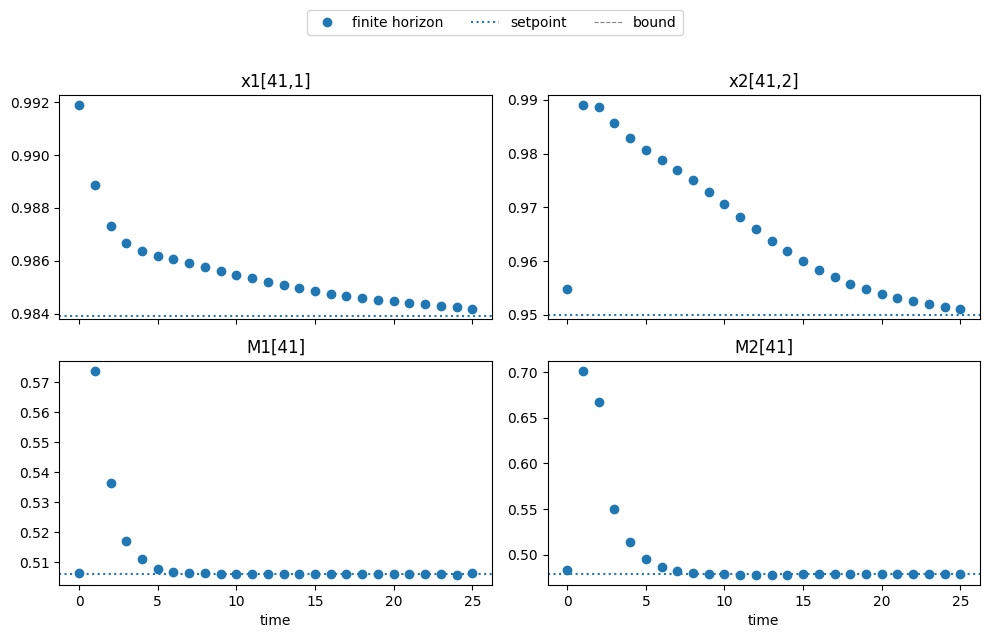

In [8]:
plot_states(m2, states=["x1[41,1]", "x2[41,2]", "M1[41]", "M2[41]"]);

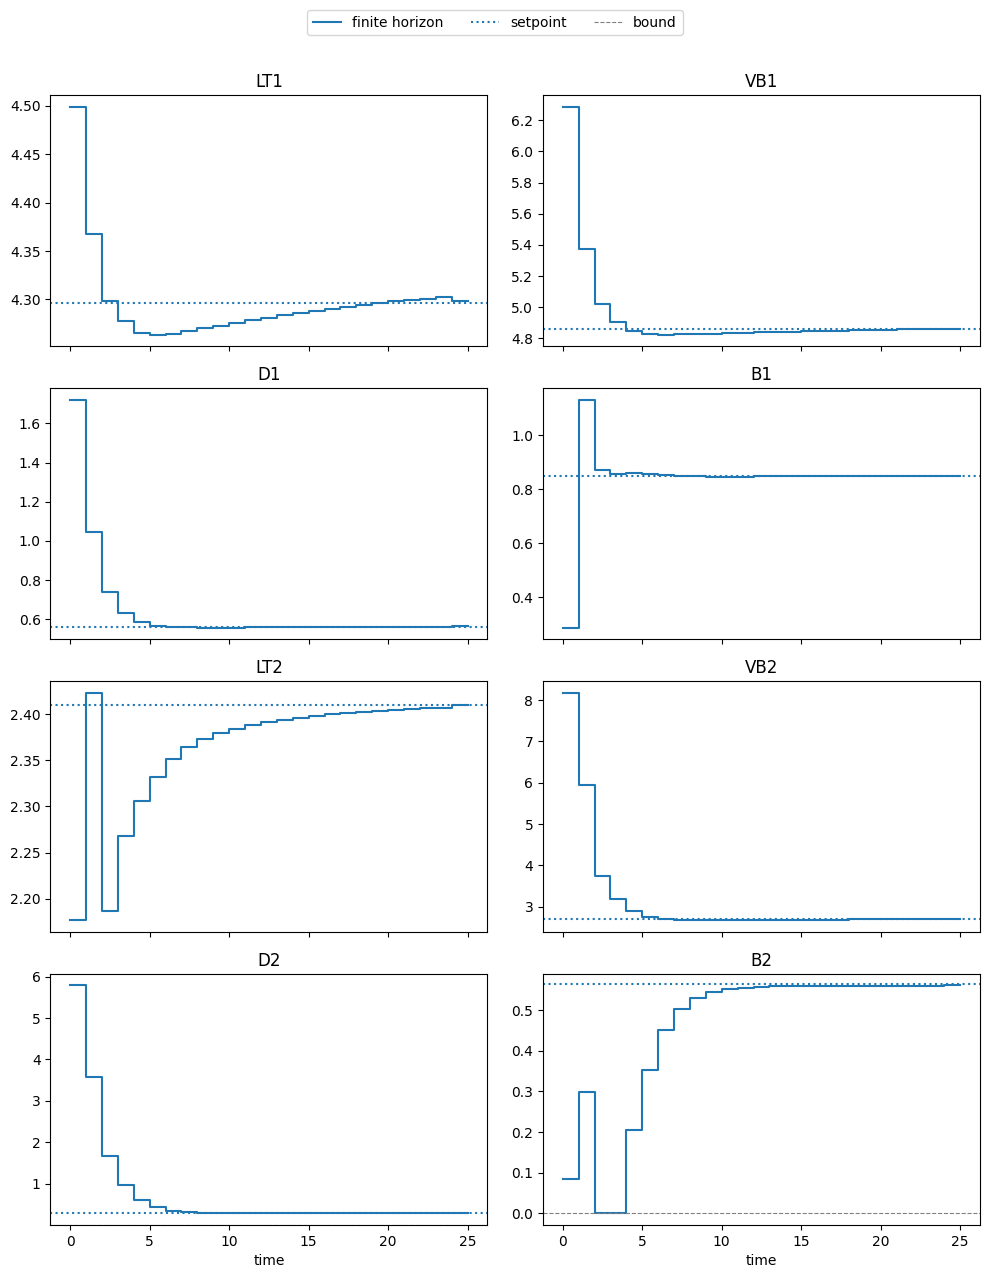

In [9]:
plot_controls(m2);

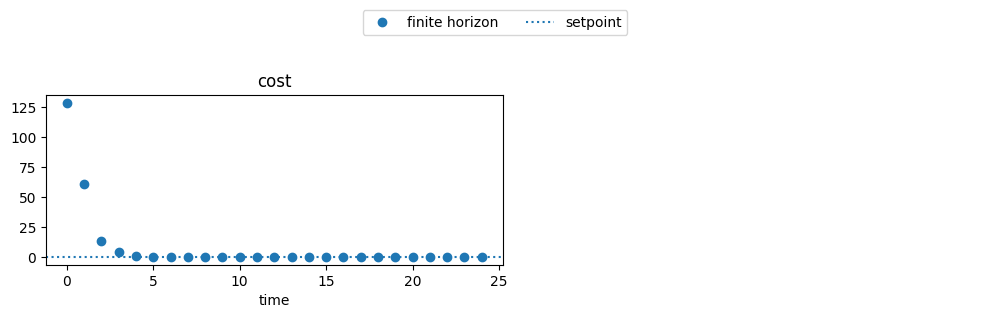

In [10]:
plot_stage_cost(m2);